# GraphSAGE v3 — AML Fraud Detection
## v2_3 → v3 변경사항
| # | 항목 | 내용 |
|---|------|------|
| 1 | **[REMOVE]** | `fraud_rate` 완전 제거 (데이터 누수) |
| 2 | **[NEW]** | Multi-scale rolling node feature (7 / 14 / 28일) — split별 ref_ts 기준, 누수 없음 |
| 4 | **[NEW]** | 글로벌 피처 2개 — `total_deg_pct`, `out_deg_pct` (split별 독립 계산) |
| 5 | **[NEW]** | 집계 함수 Sweep — mean+mean / mean+max / max+max 비교 |
| 6 | **[NEW]** | W&B에 val + test 결과, val_loss / test_loss, 전체 CFG 파라미터 기록 |
| 7 | **[KEEP]** | 28일 전체 그래프 구조, 2-layer GraphSAGE, 나머지 하이퍼파라미터 동일 |

# 0) Install & Mount

In [ ]:
!pip uninstall -y numpy
!pip install numpy==1.26.4

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_ver

In [ ]:
!pip install torch_geometric wandb -q
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch==2.2.2+cu121 torchvision==0.17.2+cu121 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.2/757.2 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 152.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 127.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 110.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 63.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 141.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip uninstall torch-geometric pyg-lib torch-sparse torch-scatter torch-cluster torch-spline-conv -y

!pip install torch-geometric
!pip install pyg-lib torch-sparse -f https://data.pyg.org/whl/torch-2.2.2+cu121.html

Found existing installation: torch-geometric 2.7.0
Uninstalling torch-geometric-2.7.0:
  Successfully uninstalled torch-geometric-2.7.0
  Using cached torch_geometric-2.7.0-py3-none-any.whl.metadata (63 kB)
Using cached torch_geometric-2.7.0-py3-none-any.whl (1.3 MB)
Looking in links: https://data.pyg.org/whl/torch-2.2.2+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 30.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 42.3 MB/s eta 0:00:00


# 1) Imports

In [ ]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, random, gc, math
from datetime import timedelta
from scipy.stats import rankdata
import wandb
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader   # ← NEW: C++ 백엔드 샘플러
from sklearn.metrics import (
    f1_score, average_precision_score, roc_auc_score,
    precision_recall_curve, confusion_matrix, classification_report
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


# 2) Config

In [ ]:
CFG = {
    'hidden_dim'    : 128,
    'aggr_l1'       : 'mean',   # aggr_combo 대신 고정 사용
    'aggr_l2'       : 'max',
    'dropout'       : 0.3,
    'emb_dim'       : 16,
    'fanout_l1'     : 25,
    'fanout_l2'     : 10,
    'temporal_days' : 28,
    'batch_size'    : 1024,
    'epochs'        : 20,
    'lr'            : 0.001,
    'weight_decay'  : 1e-4,
    'pos_weight'    : 5.0,
    'recall_target' : 0.9,
}
print(CFG)

{'hidden_dim': 128, 'aggr_l1': 'mean', 'aggr_l2': 'max', 'dropout': 0.3, 'emb_dim': 16, 'fanout_l1': 25, 'fanout_l2': 10, 'temporal_days': 28, 'batch_size': 1024, 'epochs': 20, 'lr': 0.001, 'weight_decay': 0.0001, 'pos_weight': 5.0, 'recall_target': 0.9}


# 3) Data Load & Split

In [ ]:
DATA_PATH = '/content/drive/MyDrive/data/parquet/HI-Medium_Master.parquet'

q = pl.scan_parquet(DATA_PATH)
q = q.with_columns(
    pl.col('Timestamp')
      .str.strptime(pl.Datetime, format='%Y/%m/%d %H:%M', strict=False)
      .alias('ts')
).filter(pl.col('ts').is_not_null()).sort('ts')

n         = q.select(pl.len()).collect().item()
train_cut = q.select('ts').slice(int(n * 0.6), 1).collect().item()
val_cut   = q.select('ts').slice(int(n * 0.8), 1).collect().item()

q = q.with_columns(
    pl.when(pl.col('ts') <= train_cut).then(pl.lit('train'))
      .when(pl.col('ts') <= val_cut).then(pl.lit('val'))
      .otherwise(pl.lit('test')).alias('split')
)

df        = q.collect()
test_cut  = df['ts'].max()

# split별 ref_ts 딕셔너리
REF_TS = {'train': train_cut, 'val': val_cut, 'test': test_cut}

print(f'Train cut : {train_cut}')
print(f'Val   cut : {val_cut}')
print(f'Test  cut : {test_cut}')
print(df.group_by(['split', 'Is Laundering']).agg(pl.len()).sort('split'))

Train cut : 2022-09-09 20:43:00
Val   cut : 2022-09-14 05:46:00
Test  cut : 2022-09-28 15:58:00
shape: (6, 3)
┌───────┬───────────────┬──────────┐
│ split ┆ Is Laundering ┆ len      │
│ ---   ┆ ---           ┆ ---      │
│ str   ┆ i64           ┆ u32      │
╞═══════╪═══════════════╪══════════╡
│ test  ┆ 1             ┆ 10640    │
│ test  ┆ 0             ┆ 6368318  │
│ train ┆ 0             ┆ 19124195 │
│ train ┆ 1             ┆ 15536    │
│ val   ┆ 1             ┆ 9054     │
│ val   ┆ 0             ┆ 6370926  │
└───────┴───────────────┴──────────┘


# 4) 기본 피처 (행 단위)

In [ ]:
PAYMENT_RISK_MAP = {
    'ACH':3.0, 'Bitcoin':2.5, 'Cheque':2.5,
    'Cash':1.5, 'Credit Card':1.3, 'Wire':1.0, 'Reinvestment':1.0
}
ENTITY_SCORE_MAP = {'Corporation':2.0, 'Sole Proprietorship':1.5}
HIGH_RISK_S_BANKS = [
    'National Bank of Dallas','Savings Bank of Augusta','China Bank #27',
    'India Bank #96','Brazil Bank #128','National Bank of Milford',
    'Savings Bank of Sacramento','Saudi Arabia Bank #14','Israel Bank #16',
    'Golden Credit Union'
]
HIGH_RISK_R_BANKS = [
    'China Bank #292','China Bank #27','China Bank #22','Japan Bank #143',
    'Brazil Bank #50','Bank of Denver','Saudi Arabia Bank #56',
    'Israel Bank #48','The Pine Bank','National Bank of Milford'
]

df = df.with_columns([
    pl.col('ts').dt.hour().cast(pl.Int16).alias('hour'),
    pl.col('ts').dt.weekday().is_in([6, 7]).alias('is_weekend'),
    pl.col('ts').dt.hour().is_between(0, 5).alias('is_dawn'),
    pl.when(pl.col('ts').dt.hour().is_between(0, 5)).then(pl.lit('dawn'))
      .when(pl.col('ts').dt.hour().is_between(6, 11)).then(pl.lit('morning'))
      .when(pl.col('ts').dt.hour().is_between(12, 17)).then(pl.lit('afternoon'))
      .otherwise(pl.lit('evening')).alias('timeofday'),
    pl.col('Amount_Paid_USD').cast(pl.Float32),
    pl.col('Amount_Received_USD').cast(pl.Float32),
    pl.col('Amount_Paid_USD').log1p().alias('log_amt_paid'),
    (pl.col('Amount_Paid_USD') % 1000 == 0).alias('is_round_1k'),
    (pl.col('Payment Format') == 'ACH').alias('is_ach'),
    ((pl.col('Payment Format') == 'Bitcoin') |
     (pl.col('Payment Currency') == 'Bitcoin')).alias('is_crypto'),
    pl.col('Payment Format').replace(PAYMENT_RISK_MAP, default=1.0)
      .cast(pl.Float32).alias('pay_risk'),
    pl.col('Sender_Entity').cast(pl.Utf8)
      .str.replace(r'\s*#\d+.*$', '').alias('sender_etype'),
    pl.col('Receiver_Entity').cast(pl.Utf8)
      .str.replace(r'\s*#\d+.*$', '').alias('recv_etype'),
    pl.col('Sender_Bank_Name').is_in(HIGH_RISK_S_BANKS).alias('hrisk_s_bank'),
    pl.col('Receiver_Bank_Name').is_in(HIGH_RISK_R_BANKS).alias('hrisk_r_bank'),
]).with_columns([
    (pl.col('pay_risk') * pl.col('log_amt_paid')).alias('risk_x_logamt'),
    pl.col('sender_etype').replace(ENTITY_SCORE_MAP, default=1.0)
      .cast(pl.Float32).alias('s_etype_score'),
    pl.col('recv_etype').replace(ENTITY_SCORE_MAP, default=1.0)
      .cast(pl.Float32).alias('r_etype_score'),
])

# ── bank_country: DROP 전에 여기서 생성 ────────────────────────────
def bank_country_expr(col, alias):
    c = pl.col(col).str.to_lowercase()
    return (
        pl.when(c.str.contains('china')).then(pl.lit('China'))
          .when(c.str.contains('japan')).then(pl.lit('Japan'))
          .when(c.str.contains('india')).then(pl.lit('India'))
          .when(c.str.contains('brazil')).then(pl.lit('Brazil'))
          .when(c.str.contains('saudi')).then(pl.lit('Saudi'))
          .when(c.str.contains('israel')).then(pl.lit('Israel'))
          .when(c.str.contains('russia')).then(pl.lit('Russia'))
          .when(c.str.contains('mexico')).then(pl.lit('Mexico'))
          .otherwise(pl.lit('US')).alias(alias)
    )

df = df.with_columns([
    bank_country_expr('Sender_Bank_Name',   'bank_country_s'),
    bank_country_expr('Receiver_Bank_Name', 'bank_country_r'),
])

# ── RAM 절약: bank/entity 원본 컬럼 drop (파생 피처 생성 완료 후) ──
DROP_COLS = [c for c in ['Sender_Entity','Receiver_Entity',
                          'Sender_Bank_Name','Receiver_Bank_Name']
             if c in df.columns]
if DROP_COLS:
    df = df.drop(DROP_COLS)

gc.collect()
print('기본 피처 완료 | shape:', df.shape)

기본 피처 완료 | shape: (31898669, 33)


# 5) Categorical Encoding

In [ ]:
df_tr = df.filter(pl.col('split') == 'train')
CAT_DEF = {
    'payment_fmt'   : 'Payment Format',
    'pay_currency'  : 'Payment Currency',
    'recv_currency' : 'Receiving Currency',
    'sender_etype'  : 'sender_etype',
    'recv_etype'    : 'recv_etype',
    'timeofday'     : 'timeofday',
    'bank_country_s': 'bank_country_s',
    'bank_country_r': 'bank_country_r',
}
encoders, vocab_sizes = {}, {}
for feat, col in CAT_DEF.items():
    cats = sorted(df_tr[col].drop_nulls().unique().to_list())
    c2i  = {c: i+1 for i, c in enumerate(cats)}
    encoders[feat]    = c2i
    vocab_sizes[feat] = len(cats) + 1
    df = df.with_columns(
        pl.col(col).replace(c2i, default=0).cast(pl.Int32).alias(f'c_{feat}')
    )
    print(f'  {feat:16s}: vocab={vocab_sizes[feat]}')
CAT_KEYS = list(CAT_DEF.keys())
del df_tr
print(f'\n카테고리컬 {len(CAT_KEYS)}개 완료')

  payment_fmt     : vocab=8
  pay_currency    : vocab=16
  recv_currency   : vocab=16
  sender_etype    : vocab=7
  recv_etype      : vocab=7
  timeofday       : vocab=5
  bank_country_s  : vocab=10
  bank_country_r  : vocab=10

카테고리컬 8개 완료


# 6) 노드 매핑

In [ ]:
all_accs  = np.unique(np.concatenate([
    df['From Account'].cast(pl.Utf8).to_numpy().astype(str),
    df['To Account'].cast(pl.Utf8).to_numpy().astype(str),
]))
node2id   = {a: i for i, a in enumerate(all_accs)}
NUM_NODES = len(node2id)
df = df.with_columns([
    pl.Series('src', [node2id[a] for a in df['From Account'].cast(pl.Utf8).to_list()],
              dtype=pl.Int32),
    pl.Series('dst', [node2id[a] for a in df['To Account'].cast(pl.Utf8).to_list()],
              dtype=pl.Int32),
])
print(f'Nodes: {NUM_NODES:,}  |  Rows: {len(df):,}')

Nodes: 2,076,999  |  Rows: 31,898,669


# 7) Categorical 노드 피처 (train 기준 고정)

In [ ]:
CAT_SRC = {
    'payment_fmt'   : 'c_payment_fmt',
    'pay_currency'  : 'c_pay_currency',
    'sender_etype'  : 'c_sender_etype',
    'timeofday'     : 'c_timeofday',
    'bank_country_s': 'c_bank_country_s',
}
CAT_DST = {
    'recv_currency' : 'c_recv_currency',
    'recv_etype'    : 'c_recv_etype',
    'bank_country_r': 'c_bank_country_r',
}

tr_cat = df.filter(pl.col('split') == 'train')
cat_df = pl.DataFrame({'node_id': list(range(NUM_NODES))})
for feat, col in CAT_SRC.items():
    m = (tr_cat.group_by('src')
              .agg(pl.col(col).mode().first().alias(feat))
              .rename({'src': 'node_id'}))
    cat_df = cat_df.join(m, on='node_id', how='left')
for feat, col in CAT_DST.items():
    m = (tr_cat.group_by('dst')
              .agg(pl.col(col).mode().first().alias(feat))
              .rename({'dst': 'node_id'}))
    cat_df = cat_df.join(m, on='node_id', how='left')
cat_df = cat_df.with_columns([
    pl.col(k).fill_null(0).cast(pl.Int32) for k in CAT_KEYS if k in cat_df.columns
])
cat_tensors = {k: torch.tensor(cat_df[k].to_numpy(), dtype=torch.long)
               for k in CAT_KEYS}
del tr_cat, cat_df
gc.collect()
print('카테고리 노드 피처 완료')

카테고리 노드 피처 완료


# 8) 수치 노드 피처 — split별 독립 빌드

## 설계 원칙 (누수 방지)
```
build_node_features(df, ref_ts)
  └── sub = df[ts <= ref_ts]          ← ref_ts 이전만 사용
        ├── static features (전체 이력)
        ├── 7일  rolling  (ref_ts - 7d ~ ref_ts)
        ├── 14일 rolling  (ref_ts - 14d ~ ref_ts)
        ├── 28일 rolling  (ref_ts - 28d ~ ref_ts)
        └── global percentile (total_deg_pct, out_deg_pct)
              └── rank 계산도 동일 sub 기준 → 누수 없음
```

In [ ]:
def build_node_features(df_pl, ref_ts, num_nodes):
    """
    ref_ts 이전 데이터만 사용하는 노드 피처 빌더.
    fraud_rate 없음, global percentile 포함, 완전 누수 차단.
    """
    # ── ref_ts 이전 전체 이력 ───────────────────────────────────────
    sub = df_pl.filter(pl.col('ts') <= ref_ts)

    # ── 1) Static base (전체 이력 집계) ────────────────────────────
    s_static = sub.group_by('src').agg([
        pl.len().alias('out_deg'),
        pl.col('Amount_Paid_USD').mean().alias('mean_amt_sent'),
        pl.col('Amount_Paid_USD').max().alias('max_amt_sent'),
        pl.col('Amount_Paid_USD').log1p().mean().alias('mean_log_sent'),
        pl.col('pay_risk').mean().alias('mean_pay_risk'),
        pl.col('is_ach').mean().alias('rate_ach'),
        pl.col('is_crypto').mean().alias('rate_crypto'),
        pl.col('is_round_1k').mean().alias('rate_round'),
        pl.col('s_etype_score').mean().alias('s_etype_score'),
        pl.col('hrisk_s_bank').mean().alias('rate_hrisk_sb'),
        pl.col('is_dawn').mean().alias('rate_dawn'),
        pl.col('is_weekend').mean().alias('rate_weekend'),
        pl.col('risk_x_logamt').mean().alias('mean_risk_logamt'),
    ]).rename({'src': 'node_id'})

    r_static = sub.group_by('dst').agg([
        pl.len().alias('in_deg'),
        pl.col('Amount_Received_USD').mean().alias('mean_amt_recv'),
        pl.col('Amount_Received_USD').max().alias('max_amt_recv'),
        pl.col('r_etype_score').mean().alias('r_etype_score'),
        pl.col('hrisk_r_bank').mean().alias('rate_hrisk_rb'),
    ]).rename({'dst': 'node_id'})

    # ── 2) Multi-scale rolling (7 / 14 / 28일) ─────────────────────
    roll_frames = []
    for days in [7, 14, 28]:
        w_cut = ref_ts - timedelta(days=days)
        win   = sub.filter(pl.col('ts') >= w_cut)

        if len(win) == 0:
            roll_frames.append((None, None, days))
            continue

        sw = win.group_by('src').agg([
            pl.len().alias(f'out_cnt_{days}d'),
            pl.col('Amount_Paid_USD').sum().alias(f'sum_sent_{days}d'),
            pl.col('Amount_Paid_USD').mean().alias(f'mean_sent_{days}d'),
            pl.col('Amount_Paid_USD').max().alias(f'max_sent_{days}d'),
            pl.col('is_crypto').sum().cast(pl.Float32).alias(f'cnt_crypto_{days}d'),
            pl.col('is_round_1k').sum().cast(pl.Float32).alias(f'cnt_round_{days}d'),
            pl.col('pay_risk').mean().alias(f'mean_risk_{days}d'),
            pl.col('dst').n_unique().alias(f'n_uniq_dst_{days}d'),
        ]).rename({'src': 'node_id'})

        rw = win.group_by('dst').agg([
            pl.len().alias(f'in_cnt_{days}d'),
            pl.col('Amount_Received_USD').sum().alias(f'sum_recv_{days}d'),
            pl.col('Amount_Received_USD').mean().alias(f'mean_recv_{days}d'),
            pl.col('Amount_Received_USD').max().alias(f'max_recv_{days}d'),
            pl.col('src').n_unique().alias(f'n_uniq_src_{days}d'),
        ]).rename({'dst': 'node_id'})

        roll_frames.append((sw, rw, days))

    # ── 3) 합치기 ──────────────────────────────────────────────────
    node_df = pl.DataFrame({'node_id': list(range(num_nodes))})
    node_df = node_df.join(s_static, on='node_id', how='left')
    node_df = node_df.join(r_static, on='node_id', how='left')
    for sw, rw, _ in roll_frames:
        if sw is not None:
            node_df = node_df.join(sw, on='node_id', how='left')
        if rw is not None:
            node_df = node_df.join(rw, on='node_id', how='left')

    node_df = node_df.fill_null(0.0).with_columns([
        (pl.col('out_deg') + pl.col('in_deg')).alias('total_deg'),
        (pl.col('mean_amt_sent') - pl.col('mean_amt_recv')).alias('net_flow'),
    ])

    # ── 4) Global percentile (동일 sub 기준, 누수 없음) ─────────────
    #   rankdata → [1, N], 0-indexed 후 [0,1] 정규화
    total_arr = node_df['total_deg'].to_numpy().astype(np.float64)
    out_arr   = node_df['out_deg'].to_numpy().astype(np.float64)
    denom     = max(num_nodes - 1, 1)

    total_pct = ((rankdata(total_arr, method='average') - 1) / denom).astype(np.float32)
    out_pct   = ((rankdata(out_arr,   method='average') - 1) / denom).astype(np.float32)

    node_df = node_df.with_columns([
        pl.Series('total_deg_pct', total_pct),
        pl.Series('out_deg_pct',   out_pct),
    ])

    # ── 5) 피처 컬럼 목록 ─────────────────────────────────────────
    FEAT_COLS = [
        # -- static base --
        'out_deg', 'in_deg', 'total_deg',
        'mean_amt_sent', 'max_amt_sent', 'mean_log_sent',
        'mean_amt_recv', 'max_amt_recv',
        'net_flow',
        'mean_pay_risk', 'rate_ach', 'rate_crypto', 'rate_round',
        's_etype_score', 'r_etype_score',
        'rate_hrisk_sb', 'rate_hrisk_rb',
        'rate_dawn', 'rate_weekend',
        'mean_risk_logamt',
        # -- 7일 rolling --
        'out_cnt_7d',  'sum_sent_7d',  'mean_sent_7d',  'max_sent_7d',
        'cnt_crypto_7d', 'cnt_round_7d', 'mean_risk_7d', 'n_uniq_dst_7d',
        'in_cnt_7d',   'sum_recv_7d',  'mean_recv_7d',  'max_recv_7d',  'n_uniq_src_7d',
        # -- 14일 rolling --
        'out_cnt_14d', 'sum_sent_14d', 'mean_sent_14d', 'max_sent_14d',
        'cnt_crypto_14d', 'cnt_round_14d', 'mean_risk_14d', 'n_uniq_dst_14d',
        'in_cnt_14d',  'sum_recv_14d', 'mean_recv_14d', 'max_recv_14d', 'n_uniq_src_14d',
        # -- 28일 rolling --
        'out_cnt_28d', 'sum_sent_28d', 'mean_sent_28d', 'max_sent_28d',
        'cnt_crypto_28d', 'cnt_round_28d', 'mean_risk_28d', 'n_uniq_dst_28d',
        'in_cnt_28d',  'sum_recv_28d', 'mean_recv_28d', 'max_recv_28d', 'n_uniq_src_28d',
        # -- global percentile --
        'total_deg_pct', 'out_deg_pct',
    ]
    for c in FEAT_COLS:
        if c not in node_df.columns:
            node_df = node_df.with_columns(pl.lit(0.0).alias(c))

    arr = node_df.select(FEAT_COLS).to_numpy().astype(np.float32)

    # log1p 스케일링 (percentile 제외, 금액/카운트 계열)
    PCT_COLS  = {'total_deg_pct', 'out_deg_pct'}
    RATE_COLS = {'rate_ach','rate_crypto','rate_round','rate_hrisk_sb',
                 'rate_hrisk_rb','rate_dawn','rate_weekend',
                 'mean_pay_risk','s_etype_score','r_etype_score',
                 'mean_risk_logamt','mean_log_sent'}
    LOG_KW    = ('deg','cnt','sum_','mean_amt','max_amt',
                 'mean_sent','max_sent','mean_recv','max_recv',
                 'n_uniq','net_flow')
    for idx, c in enumerate(FEAT_COLS):
        if c in PCT_COLS or c in RATE_COLS:
            continue
        if any(kw in c for kw in LOG_KW):
            arr[:, idx] = (np.log1p(np.abs(arr[:, idx]))
                           * np.sign(arr[:, idx]))

    x = torch.nan_to_num(torch.tensor(arr, dtype=torch.float),
                          nan=0., posinf=0., neginf=0.)
    return x, FEAT_COLS


# ── split별 독립 빌드 ────────────────────────────────────────────────
print('Building node features (leakage-free, per split)...')

x_train, NUM_FEATS = build_node_features(df, train_cut, NUM_NODES)
print(f'  [train] ref={train_cut} | shape={x_train.shape}')

x_val, _           = build_node_features(df, val_cut,   NUM_NODES)
print(f'  [val]   ref={val_cut}   | shape={x_val.shape}')

x_test, _          = build_node_features(df, test_cut,  NUM_NODES)
print(f'  [test]  ref={test_cut}  | shape={x_test.shape}')

print(f'\n수치 피처 수 : {len(NUM_FEATS)}')
for nm, xt in [('train',x_train), ('val',x_val), ('test',x_test)]:
    nan = torch.isnan(xt).any().item()
    inf = torch.isinf(xt).any().item()
    print(f'  {nm:5s}  NaN={nan}  Inf={inf}')

Building node features (leakage-free, per split)...
  [train] ref=2022-09-09 20:43:00 | shape=torch.Size([2076999, 61])
  [val]   ref=2022-09-14 05:46:00   | shape=torch.Size([2076999, 61])
  [test]  ref=2022-09-28 15:58:00  | shape=torch.Size([2076999, 61])

수치 피처 수 : 61
  train  NaN=False  Inf=False
  val    NaN=False  Inf=False
  test   NaN=False  Inf=False


# 9) 노드 라벨 — split별 독립

In [ ]:
def get_split_labels(df_pl, splits, num_nodes):
    sub = df_pl.filter(
        pl.col('split').is_in(splits) & (pl.col('Is Laundering') == 1)
    )
    fraud_nodes = set(sub['src'].to_list() + sub['dst'].to_list())
    y = np.zeros(num_nodes, dtype=np.float32)
    for n in fraud_nodes:
        y[n] = 1.0
    return torch.tensor(y, dtype=torch.float)


y_train = get_split_labels(df, ['train'],  NUM_NODES)
y_val   = get_split_labels(df, ['val'],    NUM_NODES)
y_test  = get_split_labels(df, ['test'],   NUM_NODES)

for name, y in [('train',y_train), ('val',y_val), ('test',y_test)]:
    print(f'y_{name}: fraud={y.mean():.4f}  ({int(y.sum()):,}/{NUM_NODES:,})')

y_train: fraud=0.0099  (20,459/2,076,999)
y_val: fraud=0.0059  (12,352/2,076,999)
y_test: fraud=0.0062  (12,867/2,076,999)


# 10) Edge Index (28일)
```
edge_index : 28일 전체 구조
importance score 계산은 제거 → NeighborLoader가 훨씬 빠름
```

In [ ]:
def build_edge_index(df_pl, ref_ts, days):
    """ref_ts 기준 과거 days일 엣지 → 양방향 edge_index"""
    cutoff = ref_ts - timedelta(days=days)
    win    = df_pl.filter((pl.col('ts') >= cutoff) & (pl.col('ts') <= ref_ts))
    if len(win) == 0:
        return torch.zeros((2, 0), dtype=torch.long)
    src_a = win['src'].to_numpy().astype(np.int64)
    dst_a = win['dst'].to_numpy().astype(np.int64)
    row = np.concatenate([src_a, dst_a])
    col = np.concatenate([dst_a, src_a])
    return torch.tensor(np.stack([row, col]), dtype=torch.long)


print('Building edge_index (28d) ...')
edge_index_train = build_edge_index(df, train_cut, CFG['temporal_days'])
edge_index_val   = build_edge_index(df, val_cut,   CFG['temporal_days'])
edge_index_test  = build_edge_index(df, test_cut,  CFG['temporal_days'])

for nm, ei in [('train',edge_index_train),('val',edge_index_val),('test',edge_index_test)]:
    print(f'  edge_index_{nm}: {ei.shape[1]:,} directed edges')

# ── RAM 절약: df에서 무거운 컬럼 정리 ──────────────────────────────
# edge_index 완성 후 src/dst 빼고 집계에 필요한 컬럼만 유지
gc.collect()
print('완료')

Building edge_index (28d) ...
  edge_index_train: 38,279,462 directed edges
  edge_index_val: 51,039,422 directed edges
  edge_index_test: 63,797,338 directed edges
완료


# 11) NeighborLoader (PyG C++ 백엔드)
```
ImportanceSampler (Python 루프) → NeighborLoader (C++ 백엔드)
속도 10~100× 향상, num_workers=2 로 CPU 병렬화
pin_memory=True 로 GPU 전송 최적화
```

In [ ]:
# ── Data 객체 ────────────────────────────────────────────────────────
data_train = Data(x=x_train, edge_index=edge_index_train,
                  y=y_train, num_nodes=NUM_NODES)
data_val   = Data(x=x_val,   edge_index=edge_index_val,
                  y=y_val,   num_nodes=NUM_NODES)
data_test  = Data(x=x_test,  edge_index=edge_index_test,
                  y=y_test,  num_nodes=NUM_NODES)


def get_seed_nodes(df_pl, split):
    d = df_pl.filter(pl.col('split') == split)
    return torch.tensor(
        list(set(d['src'].to_list() + d['dst'].to_list())),
        dtype=torch.long
    )

train_nodes = get_seed_nodes(df, 'train')
val_nodes   = get_seed_nodes(df, 'val')
test_nodes  = get_seed_nodes(df, 'test')


def make_loader(data, nodes, shuffle, cfg):
    """PyG NeighborLoader — C++ 백엔드, ImportanceSampler 대체"""
    return NeighborLoader(
        data,
        num_neighbors=[cfg['fanout_l1'], cfg['fanout_l2']],
        input_nodes=nodes,
        batch_size=cfg['batch_size'],
        shuffle=shuffle,
        num_workers=2,       # Colab은 2 권장 (4이상은 fork 오류 가능)
        pin_memory=True,     # A100 GPU 전송 최적화
    )


train_loader = make_loader(data_train, train_nodes, True,  CFG)
val_loader   = make_loader(data_val,   val_nodes,   False, CFG)
test_loader  = make_loader(data_test,  test_nodes,  False, CFG)

# ── RAM 절약: edge_index 별도 보관 불필요 (Data 안에 이미 있음) ──
del edge_index_train, edge_index_val, edge_index_test
gc.collect()

print(f'Loaders 완료 — train nodes:{len(train_nodes):,}  '
      f'val:{len(val_nodes):,}  test:{len(test_nodes):,}')

Loaders 완료 — train nodes:2,065,162  val:1,092,564  test:1,466,610


# 12) GraphSAGE v3 모델

In [ ]:
class GraphSAGEv3(nn.Module):
    """
    2-layer GraphSAGE.
    aggr_l1 / aggr_l2 각각 지정 가능: 'mean' | 'max' | 'pool'
    edge_attr 없음, fraud_rate 없음, global percentile 포함.
    """
    def __init__(self, num_numeric, vocab_sizes, cat_keys,
                 emb_dim=16, hidden_dim=128,
                 aggr_l1='mean', aggr_l2='max', dropout=0.3):
        super().__init__()
        self.cat_keys = cat_keys
        self.dropout  = dropout

        # Categorical embeddings
        self.emb = nn.ModuleDict({
            k: nn.Embedding(vocab_sizes[k], emb_dim, padding_idx=0)
            for k in cat_keys
        })
        in_dim = num_numeric + emb_dim * len(cat_keys)

        # 2-layer SAGE
        self.conv1 = SAGEConv(in_dim,     hidden_dim, aggr=aggr_l1)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim, aggr=aggr_l2)

        # Classifier head
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x, edge_index, cat):
        h = torch.cat([x] + [self.emb[k](cat[k]) for k in self.cat_keys], dim=-1)
        h = F.relu(self.conv1(h, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.conv2(h, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.head(h).squeeze(-1)


def build_model(cfg):
    """
    aggr_combo 키 우선 처리: 'mean_mean' | 'mean_max' | 'max_max'
    없으면 aggr_l1 / aggr_l2 직접 사용.
    """
    combo = cfg.get('aggr_combo', None)
    if combo is not None:
        l1, l2 = combo.split('_')
    else:
        l1 = cfg.get('aggr_l1', 'mean')
        l2 = cfg.get('aggr_l2', 'max')
    return GraphSAGEv3(
        num_numeric = len(NUM_FEATS),
        vocab_sizes = vocab_sizes,
        cat_keys    = CAT_KEYS,
        emb_dim     = cfg['emb_dim'],
        hidden_dim  = cfg['hidden_dim'],
        aggr_l1     = l1,
        aggr_l2     = l2,
        dropout     = cfg['dropout'],
    ).to(DEVICE)


model  = build_model(CFG)
in_dim = len(NUM_FEATS) + CFG['emb_dim'] * len(CAT_KEYS)
print(model)
print(f'\nin_dim : {len(NUM_FEATS)} num + {CFG["emb_dim"]}×{len(CAT_KEYS)} cat = {in_dim}')
print(f'params : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

GraphSAGEv3(
  (emb): ModuleDict(
    (payment_fmt): Embedding(8, 16, padding_idx=0)
    (pay_currency): Embedding(16, 16, padding_idx=0)
    (recv_currency): Embedding(16, 16, padding_idx=0)
    (sender_etype): Embedding(7, 16, padding_idx=0)
    (recv_etype): Embedding(7, 16, padding_idx=0)
    (timeofday): Embedding(5, 16, padding_idx=0)
    (bank_country_s): Embedding(10, 16, padding_idx=0)
    (bank_country_r): Embedding(10, 16, padding_idx=0)
  )
  (conv1): SAGEConv(189, 128, aggr=mean)
  (conv2): SAGEConv(128, 128, aggr=max)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

in_dim : 61 num + 16×8 cat = 189
params : 90,993


# 13) 평가 지표 함수

In [ ]:
def compute_metrics(labels, probs, split, recall_target=0.9):
    p, T  = split + '_', int(recall_target * 100)
    preds = (probs >= 0.5).astype(int)
    out   = {}

    out[p+'f1_05']   = f1_score(labels, preds, zero_division=0)
    out[p+'prec_05'] = float(np.where(preds.sum()>0,
                                      (labels*preds).sum()/preds.sum(), 0.))
    out[p+'rec_05']  = float(np.where(labels.sum()>0,
                                      (labels*preds).sum()/labels.sum(), 0.))

    prec_a, rec_a, thr_a = precision_recall_curve(labels, probs)
    mask = rec_a[:-1] >= recall_target
    if mask.any():
        best_thr = float(thr_a[mask][-1])
        preds_r  = (probs >= best_thr).astype(int)
        out[p+f'f1_r{T}']  = f1_score(labels, preds_r, zero_division=0)
        out[p+f'thr_r{T}'] = best_thr
    else:
        out[p+f'f1_r{T}']  = 0.0
        out[p+f'thr_r{T}'] = 0.0

    if labels.sum() > 0:
        out[p+'auprc']   = average_precision_score(labels, probs)
        out[p+'roc_auc'] = roc_auc_score(labels, probs)
    else:
        out[p+'auprc']   = 0.0
        out[p+'roc_auc'] = 0.0

    return out


def print_metrics(m, split=None):
    header = f'  {split.upper() if split else "METRICS":^40}'
    print('=' * 44)
    print(header)
    print('=' * 44)
    for k, v in m.items():
        if split is None or k.startswith(split):
            print(f'  {k:36s}: {v:.4f}')
    print('=' * 44)


def plot_pr_curve(labels, probs, auprc, split='test'):
    prec, rec, _ = precision_recall_curve(labels, probs)
    plt.figure(figsize=(6, 5))
    plt.plot(rec, prec, color='darkorange', lw=2, label=f'AUPRC={auprc:.4f}')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(f'PR Curve ({split})')
    plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()


print('Metrics utils defined.')

Metrics utils defined.


# 14) Train / Eval 함수

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, nb = 0.0, 0
    for batch in loader:
        batch  = batch.to(DEVICE)
        n_id   = batch.n_id.cpu()
        cat_s  = {k: cat_tensors[k][n_id].to(DEVICE) for k in CAT_KEYS}
        logits = model(batch.x, batch.edge_index, cat_s)
        loss   = criterion(logits[:batch.batch_size], batch.y[:batch.batch_size])
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item(); nb += 1
    return total_loss / max(nb, 1)


@torch.no_grad()
def evaluate(model, loader, criterion):
    """probs, labels, loss 반환"""
    model.eval()
    all_probs, all_labels, total_loss, nb = [], [], 0.0, 0
    for batch in loader:
        batch  = batch.to(DEVICE)
        n_id   = batch.n_id.cpu()
        cat_s  = {k: cat_tensors[k][n_id].to(DEVICE) for k in CAT_KEYS}
        logits = model(batch.x, batch.edge_index, cat_s)
        bs     = batch.batch_size
        loss   = criterion(logits[:bs], batch.y[:bs])
        total_loss += loss.item(); nb += 1
        probs  = torch.sigmoid(logits[:bs]).cpu().numpy()
        labels = batch.y[:bs].cpu().numpy()
        all_probs.append(probs); all_labels.append(labels)
    avg_loss = total_loss / max(nb, 1)
    return np.concatenate(all_probs), np.concatenate(all_labels), avg_loss


print('Train/Eval defined.')

Train/Eval defined.


# 15) W&B Sweep
> - (`mean_max`) — 비교
> - sweep 파라미터: hidden_dim / dropout / lr / pos_weight / emb_dim (5개)
> - 3^5 = 243 가지 → count=27 (Bayes 탐색)
> - val + test 결과, loss 전부 기록

In [ ]:
SWEEP_KEYS = {'hidden_dim', 'dropout', 'lr', 'pos_weight', 'emb_dim'}

sweep_config = {
    'method': 'bayes',
    'metric': {'name': 'val_auprc', 'goal': 'maximize'},
    'parameters': {
        'hidden_dim' : {'values': [128]},
        'dropout'    : {'values': [0.2, 0.3]},
        'lr'         : {'values': [1e-4, 5e-4]},
        'pos_weight' : {'values': [3.0, 5.0]},
        'emb_dim'    : {'values': [8, 16]},
        # best 파라미터 확정 후 별도 3-run으로 비교 권장
    }
}


def train_eval_sweep():
    run = wandb.init()
    wc  = wandb.config

    cfg = {
        **CFG,
        'hidden_dim' : wc.hidden_dim,
        'dropout'    : wc.dropout,
        'lr'         : wc.lr,
        'pos_weight' : wc.pos_weight,
        'emb_dim'    : wc.emb_dim,
    }
    fixed_params = {k: v for k, v in CFG.items() if k not in SWEEP_KEYS}
    wandb.config.update(fixed_params, allow_val_change=True)

    _model = build_model(cfg).to(DEVICE)
    _opt   = torch.optim.Adam(_model.parameters(),
                               lr=cfg['lr'],
                               weight_decay=cfg['weight_decay'])
    _crit  = nn.BCEWithLogitsLoss(
                 pos_weight=torch.tensor([cfg['pos_weight']]).to(DEVICE))

    # NeighborLoader: esc 인자 없음
    _tr_ldr = make_loader(data_train, train_nodes, True,  cfg)
    _vl_ldr = make_loader(data_val,   val_nodes,   False, cfg)
    _te_ldr = make_loader(data_test,  test_nodes,  False, cfg)

    best_val_auprc = 0.0
    T = int(cfg['recall_target'] * 100)

    for epoch in range(1, cfg['epochs'] + 1):
        train_loss = train_epoch(_model, _tr_ldr, _opt, _crit)

        vp, vl, val_loss  = evaluate(_model, _vl_ldr, _crit)
        tp, tl, test_loss = evaluate(_model, _te_ldr, _crit)

        vm = compute_metrics(vl, vp, 'val',  cfg['recall_target'])
        tm = compute_metrics(tl, tp, 'test', cfg['recall_target'])

        log_dict = {
            'epoch'         : epoch,
            'train_loss'    : train_loss,
            'val_loss'      : val_loss,
            'test_loss'     : test_loss,
            'val_auprc'     : vm['val_auprc'],
            'val_roc_auc'   : vm['val_roc_auc'],
            'val_f1_05'     : vm['val_f1_05'],
            'val_prec_05'   : vm['val_prec_05'],
            'val_rec_05'    : vm['val_rec_05'],
            f'val_f1_r{T}'  : vm[f'val_f1_r{T}'],
            'test_auprc'    : tm['test_auprc'],
            'test_roc_auc'  : tm['test_roc_auc'],
            'test_f1_05'    : tm['test_f1_05'],
            'test_prec_05'  : tm['test_prec_05'],
            'test_rec_05'   : tm['test_rec_05'],
            f'test_f1_r{T}' : tm[f'test_f1_r{T}'],
        }
        wandb.log(log_dict)

        if vm['val_auprc'] > best_val_auprc:
            best_val_auprc = vm['val_auprc']

        print(f"  [{epoch:02d}/{cfg['epochs']}]  "
              f"tr_loss={train_loss:.4f}  "
              f"vl_loss={val_loss:.4f}  "
              f"te_loss={test_loss:.4f}  │  "
              f"val_auprc={vm['val_auprc']:.4f}  "
              f"test_auprc={tm['test_auprc']:.4f}")

    wandb.summary['best_val_auprc']    = best_val_auprc
    wandb.summary['final_val_f1']      = vm['val_f1_05']
    wandb.summary['final_test_auprc']  = tm['test_auprc']
    wandb.summary['final_test_f1']     = tm['test_f1_05']
    run.finish()

    # ── sweep run마다 GPU 메모리 명시 해제 ─────────────────────────
    del _model, _opt, _crit, _tr_ldr, _vl_ldr, _te_ldr
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()


sweep_id = wandb.sweep(sweep_config, project='eungyulwon')
wandb.agent(sweep_id, function=train_eval_sweep, count=12)  # Bayes 12회
print('\nSweep 완료!')

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Create sweep with ID: tyr1acp9
Sweep URL: https://wandb.ai/0326byeol-korea-ac-kr/eungyulwon/sweeps/tyr1acp9


wandb: Agent Starting Run: z1mu2md0 with config:
wandb: 	dropout: 0.3
wandb: 	emb_dim: 8
wandb: 	hidden_dim: 128
wandb: 	lr: 0.0001
wandb: 	pos_weight: 3
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: hyo9 (0326byeol-korea-ac-kr) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


  [01/20]  tr_loss=0.1221  vl_loss=0.1277  te_loss=0.1788  │  val_auprc=0.0782  test_auprc=0.0773
  [02/20]  tr_loss=0.1028  vl_loss=0.1158  te_loss=0.1845  │  val_auprc=0.1356  test_auprc=0.0965
  [03/20]  tr_loss=0.0977  vl_loss=0.1129  te_loss=0.1814  │  val_auprc=0.1686  test_auprc=0.0891
  [04/20]  tr_loss=0.0941  vl_loss=0.1112  te_loss=0.1610  │  val_auprc=0.2104  test_auprc=0.0973
  [05/20]  tr_loss=0.0914  vl_loss=0.1114  te_loss=0.1468  │  val_auprc=0.2356  test_auprc=0.1088
  [06/20]  tr_loss=0.0892  vl_loss=0.1160  te_loss=0.1419  │  val_auprc=0.2599  test_auprc=0.1102
  [07/20]  tr_loss=0.0878  vl_loss=0.1105  te_loss=0.1563  │  val_auprc=0.2763  test_auprc=0.0964
  [08/20]  tr_loss=0.0865  vl_loss=0.1029  te_loss=0.1630  │  val_auprc=0.2716  test_auprc=0.0979
  [09/20]  tr_loss=0.0856  vl_loss=0.1030  te_loss=0.1590  │  val_auprc=0.2824  test_auprc=0.0993
  [10/20]  tr_loss=0.0845  vl_loss=0.1021  te_loss=0.1439  │  val_auprc=0.2983  test_auprc=0.0960
  [11/20]  tr_loss=0

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_auprc,▁▄▃▄▆▇▄▅▅▄▃▅▄▄▄▆▆▅▅█
test_f1_05,▁▁▁▂▃▅▄▂▄▅▄▅▄▆▄▆▅▅▇█
test_f1_r90,▁▃▅▆▇█▆▇▇█▇▆▇▇▆▇▆▇▆█
test_loss,▇██▄▂▂▄▅▄▂▆▆▆▄▂▄▁▃▃▁
test_prec_05,▁▁██████████████████
test_rec_05,▁▁▁▂▃▅▄▂▄▅▄▅▄▆▄▆▅▅▇█
test_roc_auc,▁▄▆▇██▇█▇█▇▇▇▇▇▇▇█▇█
train_loss,█▅▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_auprc,▁▃▄▅▅▆▇▆▇▇▇▇▇█▇█████
+6,...


...

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_auprc,▆▃▄▃▁▄▅▄▂▃▆▄▄█▇▆▃▅▅▆
test_f1_05,▁▂▂▂▃▄▆▅▃▅▇▄▅██▆▅▇▄█
test_f1_r90,▆▆▇█▆▃▇▆▆▆█▆▄▇▆▆▃▁▄▇
test_loss,█▃▂▅▄▃▁▃▄▃▁▃▅▄▂▃▅█▄▄
test_prec_05,██████▇▇█▇▆▇▇▄▁▆▇▆▇▄
test_rec_05,▁▂▂▂▃▄▆▅▃▅▇▄▅██▆▅▇▄█
test_roc_auc,▇▆██▆▄▇▇▅▅█▇▄▇▇▆▃▁▅▇
train_loss,█▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_auprc,▁▃▄▄▅▆▇▇▆▇▇▅▇█▆▇▆▇▇█
+6,...


wandb: Agent Starting Run: hedq5678 with config:
wandb: 	dropout: 0.2
wandb: 	emb_dim: 8
wandb: 	hidden_dim: 128
wandb: 	lr: 0.0005
wandb: 	pos_weight: 5
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


  [01/20]  tr_loss=0.1486  vl_loss=0.1647  te_loss=0.2260  │  val_auprc=0.1657  test_auprc=0.0907
  [02/20]  tr_loss=0.1306  vl_loss=0.1622  te_loss=0.1873  │  val_auprc=0.2489  test_auprc=0.1095
  [03/20]  tr_loss=0.1238  vl_loss=0.1532  te_loss=0.2138  │  val_auprc=0.2831  test_auprc=0.0978
  [04/20]  tr_loss=0.1213  vl_loss=0.1529  te_loss=0.1688  │  val_auprc=0.2649  test_auprc=0.0949
  [05/20]  tr_loss=0.1188  vl_loss=0.1513  te_loss=0.1606  │  val_auprc=0.2976  test_auprc=0.0825
  [06/20]  tr_loss=0.1178  vl_loss=0.1470  te_loss=0.1790  │  val_auprc=0.2913  test_auprc=0.0761
  [07/20]  tr_loss=0.1175  vl_loss=0.1440  te_loss=0.1725  │  val_auprc=0.3095  test_auprc=0.0826
  [08/20]  tr_loss=0.1169  vl_loss=0.1391  te_loss=0.2027  │  val_auprc=0.3183  test_auprc=0.0911
  [09/20]  tr_loss=0.1161  vl_loss=0.1374  te_loss=0.1803  │  val_auprc=0.3087  test_auprc=0.0881
  [10/20]  tr_loss=0.1150  vl_loss=0.1390  te_loss=0.2105  │  val_auprc=0.3141  test_auprc=0.0989
  [11/20]  tr_loss=0

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_auprc,▃▆▄▄▂▁▂▃▃▄▄▄▆▅▄▇█▂▂▄
test_f1_05,▁▃▄▂▃▃▄▅▄▆▄▅▆▄▅▇█▃▅▄
test_f1_r90,▁▃▆▆▆▆█▄▇▅▆▅▇▇▃▄▇▆▁▆
test_loss,▇▃▆▂▁▃▂▅▃▅▄▄▂▆▃▁▁▄█▇
test_prec_05,██▇██████▆▅▇▆▇▆▄▁█▇█
test_rec_05,▁▃▄▂▃▃▄▅▄▆▄▅▆▄▅▇█▃▅▄
test_roc_auc,▁▅▅▆▅▅▆▃▇▅▇▅▆█▅▆█▅▁▆
train_loss,█▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_auprc,▁▄▆▅▆▆▇▇▇▇▇██▇███▆█▇
+6,...



Sweep 완료!


# 16) Sweep Best Config → 최종 학습

In [ ]:
api   = wandb.Api()
runs  = api.runs('eungyulwon', filters={'sweep': sweep_id})
best  = sorted(runs, key=lambda r: r.summary.get('best_val_auprc', 0), reverse=True)[0]

KEY_PARAMS = ['hidden_dim','dropout','lr','pos_weight','emb_dim','aggr_combo',
              'fanout_l1','fanout_l2','temporal_days','imp_days','imp_ratio',
              'batch_size','epochs','weight_decay','recall_target']
print('Best Run   :', best.name)
print('Config     :', {k: v for k, v in best.config.items() if k in KEY_PARAMS})
print('Val AUPRC  :', best.summary.get('best_val_auprc'))
print('Test AUPRC :', best.summary.get('final_test_auprc'))
print('aggr_combo :', best.summary.get('aggr_combo'))

BEST_CFG = {
    **CFG,
    'hidden_dim' : best.config['hidden_dim'],
    'dropout'    : best.config['dropout'],
    'lr'         : best.config['lr'],
    'pos_weight' : best.config['pos_weight'],
    'emb_dim'    : best.config['emb_dim'],
}
print('\nBEST_CFG :', BEST_CFG)

Best Run   : copper-sweep-10
Config     : {'lr': 0.0001, 'epochs': 20, 'dropout': 0.2, 'emb_dim': 8, 'fanout_l1': 25, 'fanout_l2': 10, 'batch_size': 1024, 'hidden_dim': 128, 'pos_weight': 5, 'weight_decay': 0.0001, 'recall_target': 0.9, 'temporal_days': 28}
Val AUPRC  : 0.3367260308308082
Test AUPRC : 0.10267557832120212
aggr_combo : None

BEST_CFG : {'hidden_dim': 128, 'aggr_l1': 'mean', 'aggr_l2': 'max', 'dropout': 0.2, 'emb_dim': 8, 'fanout_l1': 25, 'fanout_l2': 10, 'temporal_days': 28, 'batch_size': 1024, 'epochs': 20, 'lr': 0.0001, 'weight_decay': 0.0001, 'pos_weight': 5, 'recall_target': 0.9}


In [ ]:
# ── 최종 학습 (전체 CFG 파라미터 W&B에 기록) ─────────────────────────
run = wandb.init(project='eungyulwon', name='final_best_v3', config=BEST_CFG)
wandb.config.update(BEST_CFG, allow_val_change=True)

model     = build_model(BEST_CFG).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(),
                              lr=BEST_CFG['lr'],
                              weight_decay=BEST_CFG['weight_decay'])
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([BEST_CFG['pos_weight']]).to(DEVICE))

# NeighborLoader: esc 인자 없음
train_loader = make_loader(data_train, train_nodes, True,  BEST_CFG)
val_loader   = make_loader(data_val,   val_nodes,   False, BEST_CFG)
test_loader  = make_loader(data_test,  test_nodes,  False, BEST_CFG)

history = {
    'train_loss':[], 'val_loss':[], 'test_loss':[],
    'val_auprc':[], 'val_f1_05':[], 'val_roc_auc':[],
    'test_auprc':[], 'test_f1_05':[], 'test_roc_auc':[],
}
T = int(BEST_CFG['recall_target'] * 100)

for epoch in range(1, BEST_CFG['epochs'] + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)

    vp, vl, val_loss  = evaluate(model, val_loader,  criterion)
    tp, tl, test_loss = evaluate(model, test_loader, criterion)

    vm = compute_metrics(vl, vp, 'val',  BEST_CFG['recall_target'])
    tm = compute_metrics(tl, tp, 'test', BEST_CFG['recall_target'])

    for k, v in [('train_loss', train_loss), ('val_loss', val_loss), ('test_loss', test_loss),
                 ('val_auprc',  vm['val_auprc']),  ('val_f1_05',  vm['val_f1_05']),
                 ('val_roc_auc',vm['val_roc_auc']),
                 ('test_auprc', tm['test_auprc']), ('test_f1_05', tm['test_f1_05']),
                 ('test_roc_auc',tm['test_roc_auc'])]:
        history[k].append(v)

    wandb.log({
        'epoch'         : epoch,
        'train_loss'    : train_loss,
        'val_loss'      : val_loss,
        'test_loss'     : test_loss,
        'val_auprc'     : vm['val_auprc'],
        'val_roc_auc'   : vm['val_roc_auc'],
        'val_f1_05'     : vm['val_f1_05'],
        'val_prec_05'   : vm['val_prec_05'],
        'val_rec_05'    : vm['val_rec_05'],
        f'val_f1_r{T}'  : vm[f'val_f1_r{T}'],
        'test_auprc'    : tm['test_auprc'],
        'test_roc_auc'  : tm['test_roc_auc'],
        'test_f1_05'    : tm['test_f1_05'],
        'test_prec_05'  : tm['test_prec_05'],
        'test_rec_05'   : tm['test_rec_05'],
        f'test_f1_r{T}' : tm[f'test_f1_r{T}'],
    })

    print(f"[{epoch:02d}/{BEST_CFG['epochs']}]  "
          f"tr={train_loss:.4f}  vl={val_loss:.4f}  te={test_loss:.4f}  │  "
          f"val_auprc={vm['val_auprc']:.4f}  test_auprc={tm['test_auprc']:.4f}  "
          f"val_f1={vm['val_f1_05']:.4f}  test_f1={tm['test_f1_05']:.4f}")

run.finish()
print('\nTraining complete!')

wandb: WARNING Config item 'hidden_dim' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'dropout' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'emb_dim' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'lr' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'pos_weight' was locked by 'sweep' (ignored update).


[01/20]  tr=0.1664  vl=0.1727  te=0.2981  │  val_auprc=0.1078  test_auprc=0.0812  val_f1=0.0814  test_f1=0.0000
[02/20]  tr=0.1399  vl=0.1642  te=0.2706  │  val_auprc=0.1538  test_auprc=0.0958  val_f1=0.1545  test_f1=0.0029
[03/20]  tr=0.1332  vl=0.1601  te=0.2564  │  val_auprc=0.1982  test_auprc=0.1077  val_f1=0.2509  test_f1=0.0148
[04/20]  tr=0.1288  vl=0.1603  te=0.2260  │  val_auprc=0.2423  test_auprc=0.1097  val_f1=0.2924  test_f1=0.0221
[05/20]  tr=0.1250  vl=0.1605  te=0.1925  │  val_auprc=0.2712  test_auprc=0.1188  val_f1=0.3231  test_f1=0.0271
[06/20]  tr=0.1222  vl=0.1463  te=0.2320  │  val_auprc=0.2775  test_auprc=0.1080  val_f1=0.3293  test_f1=0.0267
[07/20]  tr=0.1200  vl=0.1503  te=0.2056  │  val_auprc=0.2917  test_auprc=0.1070  val_f1=0.3512  test_f1=0.0339
[08/20]  tr=0.1185  vl=0.1443  te=0.2583  │  val_auprc=0.2935  test_auprc=0.1044  val_f1=0.3321  test_f1=0.0183
[09/20]  tr=0.1170  vl=0.1434  te=0.2382  │  val_auprc=0.2977  test_auprc=0.0976  val_f1=0.3513  test_f1

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
test_auprc,▁▃▄▄▅▄▄▄▃▅▄▇▆▄▅▆▄▇▅█
test_f1_05,▁▁▂▃▃▃▄▃▄▄▅█▅▅▆█▄█▇█
test_f1_r90,▁▄▅▆▇▇▇▇▆▇▇▇▇███████
test_loss,█▆▆▄▂▄▃▆▅▂▃▂▃▃▂▁▂▁▂▃
test_prec_05,▁██████████▇██▇▇█▇▇▇
test_rec_05,▁▁▂▃▃▃▄▂▃▄▅█▅▅▆█▄█▇█
test_roc_auc,▁▅▆▆▇▇▇▇▇▇▇▇▇██▇▇███
train_loss,█▅▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_auprc,▁▂▄▅▆▆▇▇▇▇▇█▇▇▇▇▇███
+6,...



Training complete!


# 17) 결과 시각화

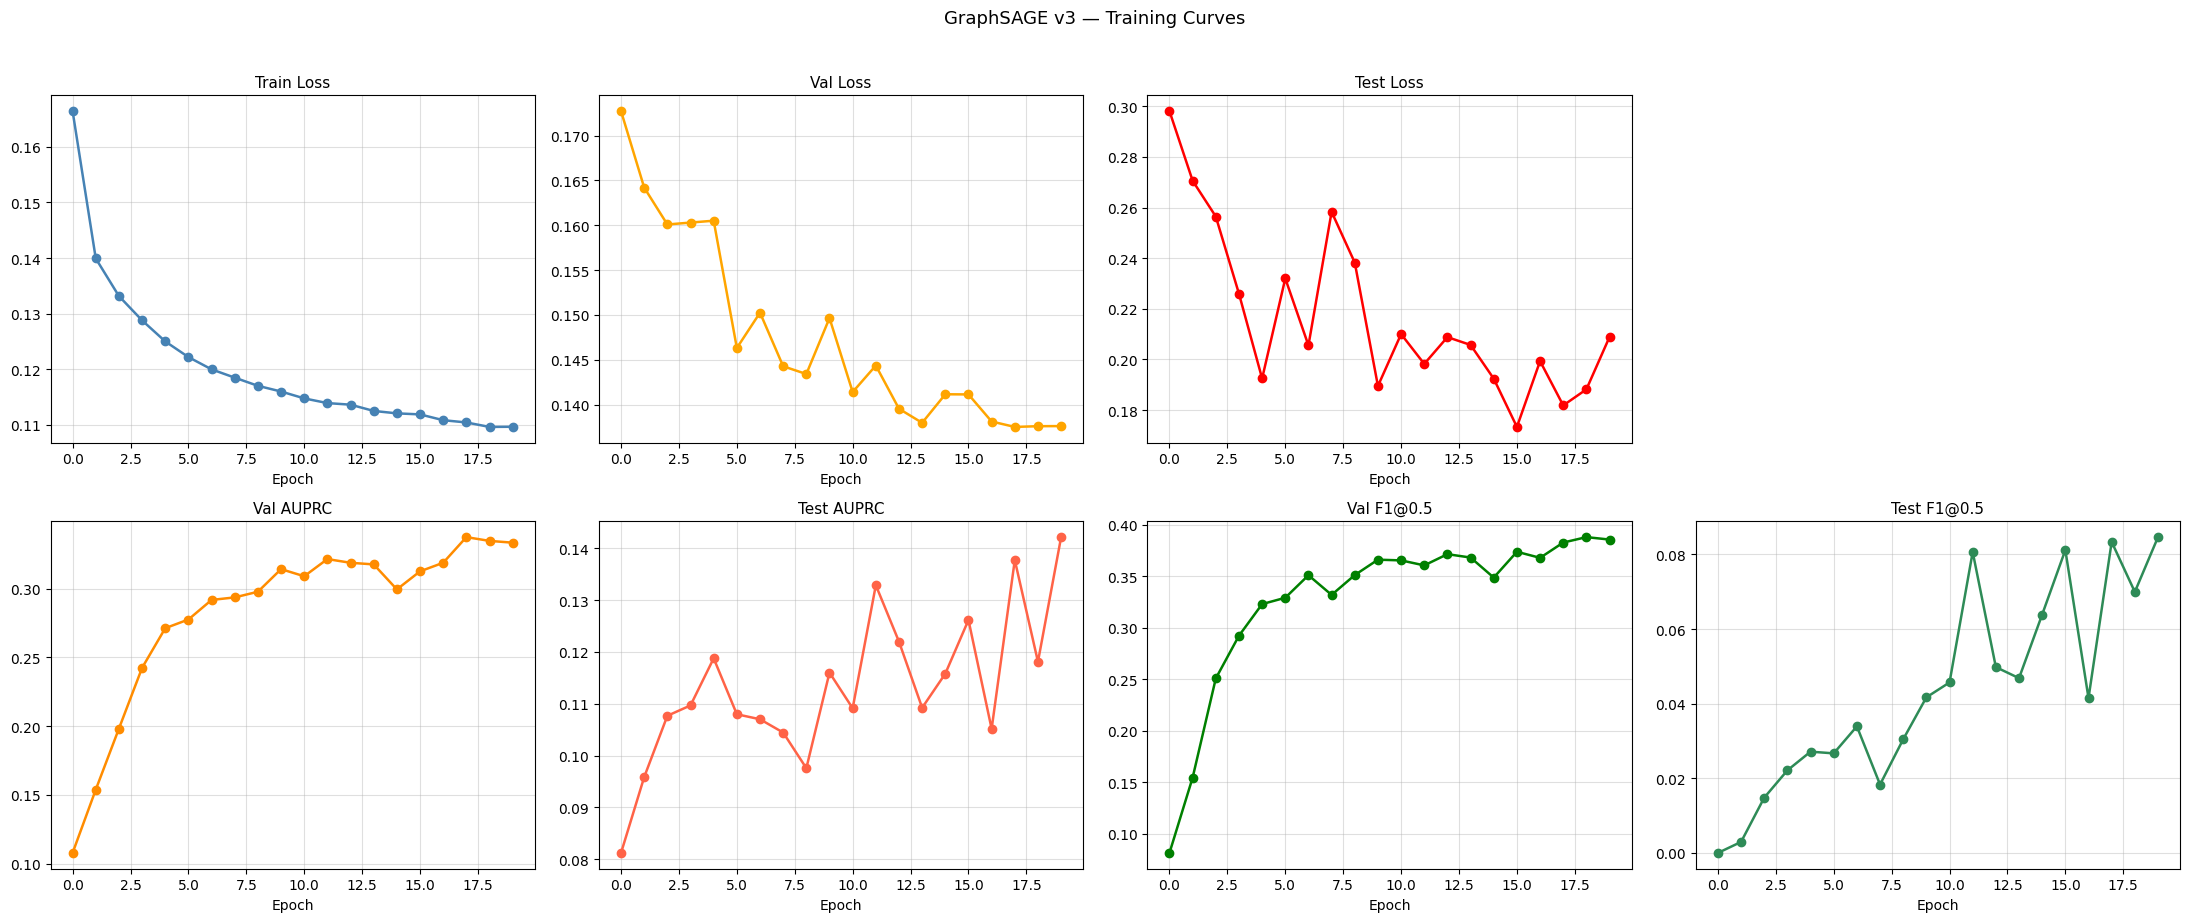

                    VAL                   
  val_f1_05                           : 0.3906
  val_prec_05                         : 0.5049
  val_rec_05                          : 0.3185
  val_f1_r90                          : 0.0732
  val_thr_r90                         : 0.0687
  val_auprc                           : 0.3377
  val_roc_auc                         : 0.9144
                    TEST                  
  test_f1_05                          : 0.0871
  test_prec_05                        : 0.8234
  test_rec_05                         : 0.0460
  test_f1_r90                         : 0.0367
  test_thr_r90                        : 0.0003
  test_auprc                          : 0.1419
  test_roc_auc                        : 0.8442


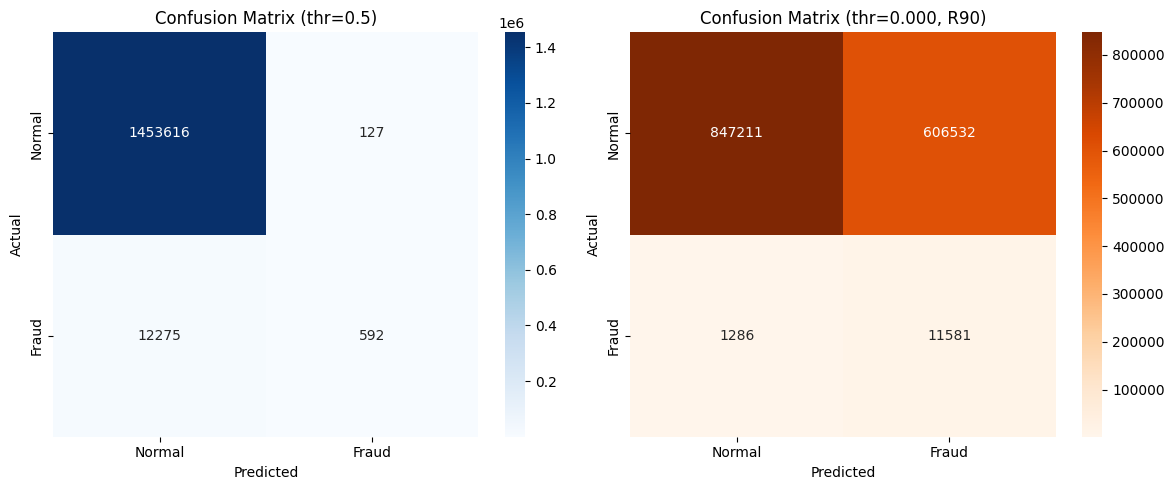

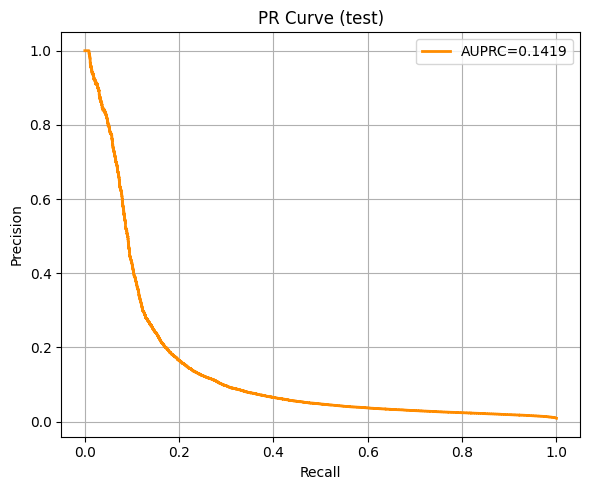

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00   1453743
       Fraud       0.82      0.05      0.09     12867

    accuracy                           0.99   1466610
   macro avg       0.91      0.52      0.54   1466610
weighted avg       0.99      0.99      0.99   1466610



In [ ]:
# ── 학습 곡선 ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
curves = [
    # row 0: loss
    ('train_loss',   'Train Loss',    'steelblue'),
    ('val_loss',     'Val Loss',      'orange'),
    ('test_loss',    'Test Loss',     'red'),
    (None, None, None),                           # 빈 칸
    # row 1: metrics
    ('val_auprc',    'Val AUPRC',     'darkorange'),
    ('test_auprc',   'Test AUPRC',    'tomato'),
    ('val_f1_05',    'Val F1@0.5',    'green'),
    ('test_f1_05',   'Test F1@0.5',   'seagreen'),
]
for ax, (key, label, c) in zip(axes.flatten(), curves):
    if key is None:
        ax.axis('off'); continue
    ax.plot(history[key], marker='o', color=c, linewidth=1.8)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Epoch'); ax.grid(True, alpha=0.4)
plt.suptitle('GraphSAGE v3 — Training Curves', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ── 최종 지표 출력 ───────────────────────────────────────────────────
vp, vl, _ = evaluate(model, val_loader,  criterion)
tp, tl, _ = evaluate(model, test_loader, criterion)

val_m  = compute_metrics(vl, vp, 'val',  BEST_CFG['recall_target'])
test_m = compute_metrics(tl, tp, 'test', BEST_CFG['recall_target'])

print_metrics(val_m,  split='val')
print_metrics(test_m, split='test')

# ── Confusion Matrix ─────────────────────────────────────────────────
T = int(BEST_CFG['recall_target'] * 100)
best_thr = test_m.get(f'test_thr_r{T}', 0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, thr, cmap, title in [
    (axes[0], 0.5,     'Blues',   'Confusion Matrix (thr=0.5)'),
    (axes[1], best_thr,'Oranges', f'Confusion Matrix (thr={best_thr:.3f}, R{T})'),
]:
    cm = confusion_matrix(tl, (tp >= thr).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Normal','Fraud'],
                yticklabels=['Normal','Fraud'], ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

# ── PR Curve ─────────────────────────────────────────────────────────
plot_pr_curve(tl, tp, test_m['test_auprc'], split='test')
print(classification_report(tl, (tp >= 0.5).astype(int),
      target_names=['Normal','Fraud'], zero_division=0))

# 18) Permutation Importance

In [ ]:
@torch.no_grad()
def eval_custom(model, loader, x_ov, cat_ov):
    model.eval()
    all_p, all_l = [], []
    for batch in loader:
        n_id  = batch.n_id.cpu()
        x_s   = x_ov[n_id].to(DEVICE)
        cat_s = {k: cat_ov[k][n_id].to(DEVICE) for k in CAT_KEYS}
        ei    = batch.edge_index.to(DEVICE)
        p = torch.sigmoid(model(x_s, ei, cat_s))[:batch.batch_size].cpu().numpy()
        l = batch.y[:batch.batch_size].cpu().numpy()
        all_p.append(p); all_l.append(l)
    return np.concatenate(all_p), np.concatenate(all_l)


def permutation_importance(model, loader, x_val_t, cat_t,
                            num_names, cat_names, n_repeats=3, seed=42):
    rng = np.random.default_rng(seed)
    bp, bl   = eval_custom(model, loader, x_val_t, cat_t)
    baseline = average_precision_score(bl, bp)
    print(f'Baseline AUPRC: {baseline:.4f}')

    imp_num, imp_cat = {}, {}
    print(f'Permuting {len(num_names)} numeric features...')
    x_w = x_val_t.clone()
    for idx, fname in enumerate(num_names):
        drops = []
        for _ in range(n_repeats):
            xp = x_w.clone()
            pm = rng.permutation(xp.shape[0])
            xp[:, idx] = xp[pm, idx]
            pp, pl = eval_custom(model, loader, xp, cat_t)
            drops.append(baseline - average_precision_score(pl, pp))
        imp_num[fname] = float(np.mean(drops))
        if (idx + 1) % 10 == 0:
            print(f'  [{idx+1}/{len(num_names)}] done')

    print(f'Permuting {len(cat_names)} categorical features...')
    for k in cat_names:
        drops = []
        for _ in range(n_repeats):
            cp  = {kk: cat_t[kk].clone() for kk in CAT_KEYS}
            pm  = rng.permutation(len(cp[k]))
            cp[k] = cp[k][pm]
            pp, pl = eval_custom(model, loader, x_val_t, cp)
            drops.append(baseline - average_precision_score(pl, pp))
        imp_cat[k] = float(np.mean(drops))

    return imp_num, imp_cat, baseline


print('Permutation Importance utilities defined.')

Permutation Importance utilities defined.


Running Permutation Importance (val set)...
Baseline AUPRC: 0.3363
Permuting 61 numeric features...
  [10/61] done
  [20/61] done
  [30/61] done
  [40/61] done
  [50/61] done
  [60/61] done
Permuting 8 categorical features...


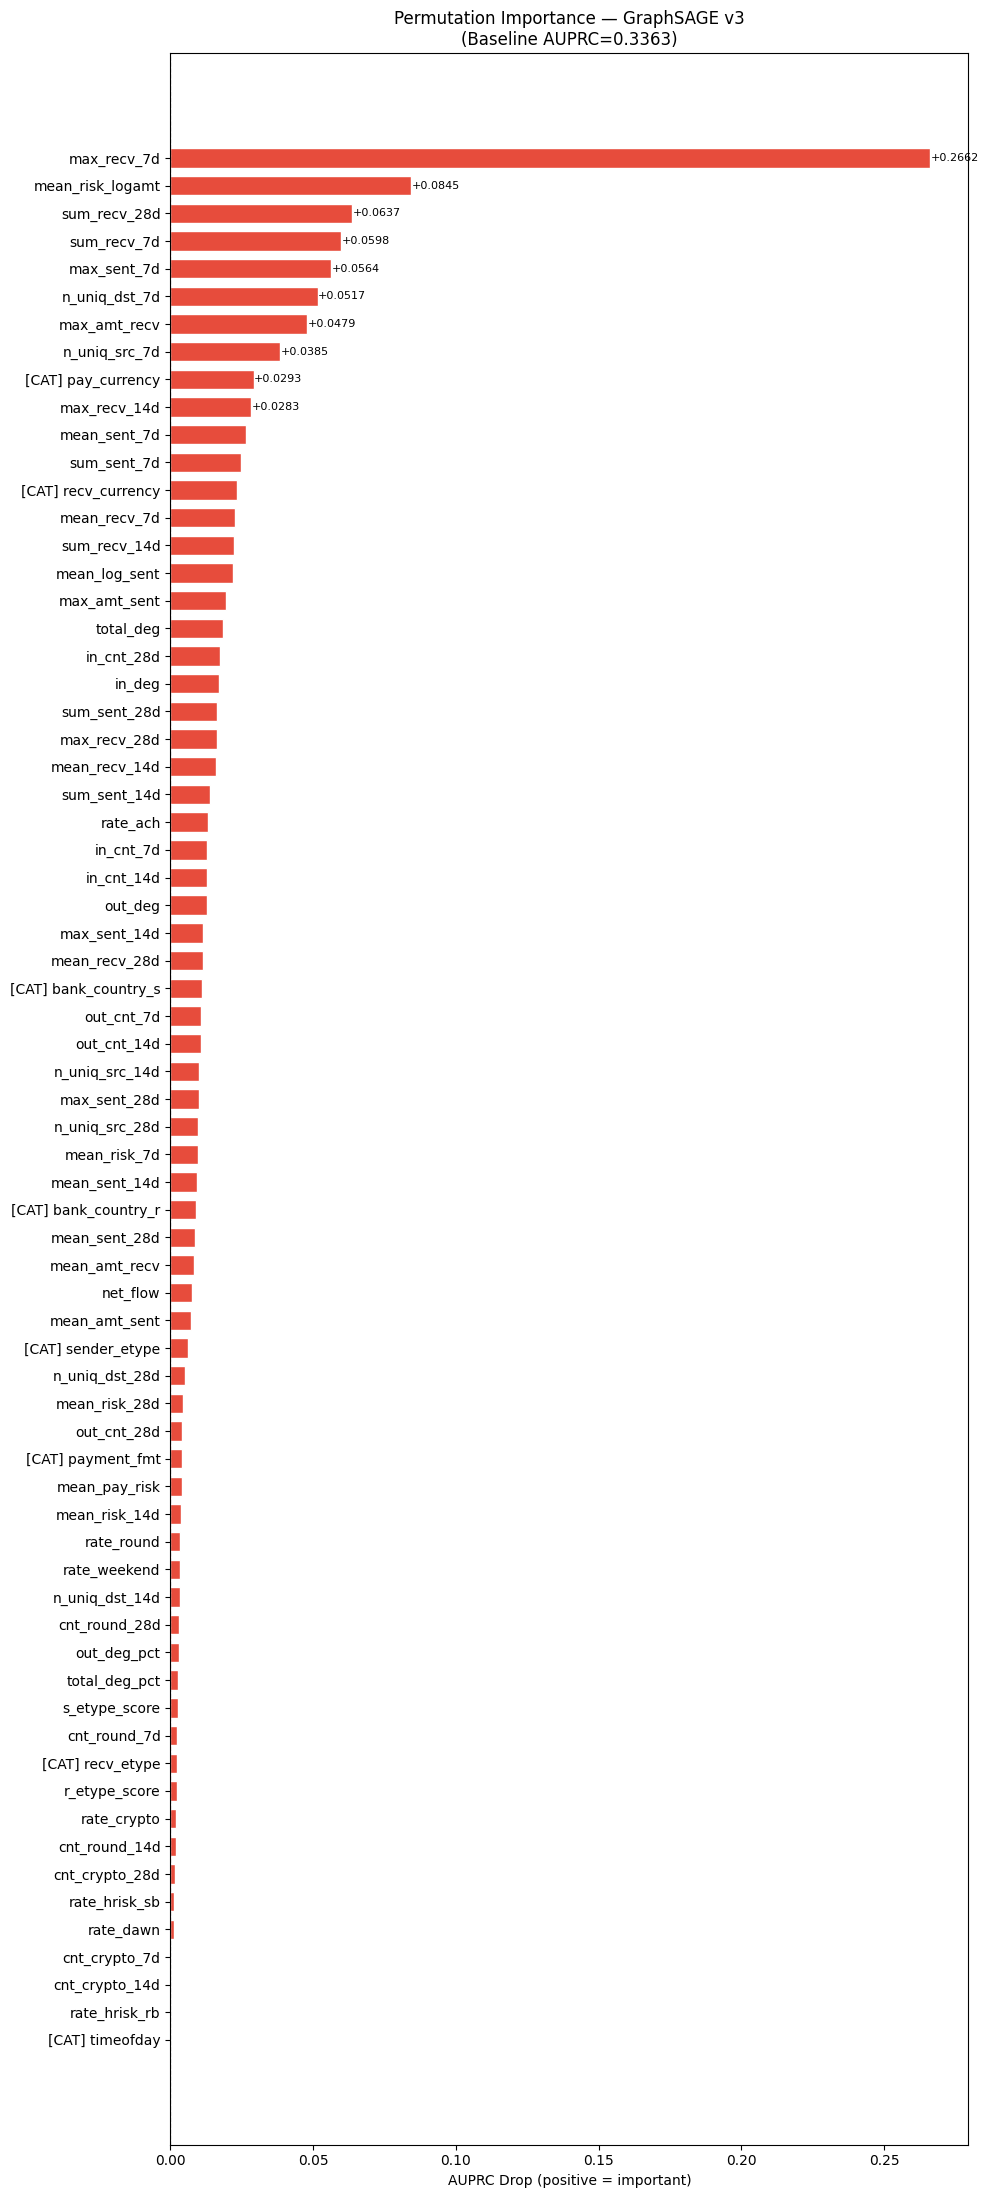


Top-10 Most Important Features:
-------------------------------------------------------
   1. max_recv_7d                                   +0.2662  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2. mean_risk_logamt                              +0.0845  ██████████████████████████████████████████
   3. sum_recv_28d                                  +0.0637  ███████████████████████████████
   4. sum_recv_7d                                   +0.0598  █████████████████████████████
   5. max_sent_7d                                   +0.0564  ████████████████████████████
   6. n_uniq_dst_7d                                 +0.0517  █████████████████████████
   7. max_amt_recv                                  +0.0479  ███████████████████████
   8. n_uniq_src_7d                                 +0.0385  ███████████████████
   9. [CAT] pay_currency                            +0.0293  ██████████████
  10. max

In [ ]:
print('Running Permutation Importance (val set)...')
imp_num, imp_cat, baseline_auprc = permutation_importance(
    model, val_loader, x_val, cat_tensors,
    NUM_FEATS, CAT_KEYS, n_repeats=3, seed=SEED
)

all_imp    = {**imp_num, **{f'[CAT] {k}': v for k, v in imp_cat.items()}}
sorted_imp = sorted(all_imp.items(), key=lambda x: x[1], reverse=True)
names, values = [x[0] for x in sorted_imp], [x[1] for x in sorted_imp]
colors = ['#e74c3c' if v > 0 else '#3498db' for v in values]

fig, ax = plt.subplots(figsize=(10, max(6, len(names)*0.32)))
bars = ax.barh(names, values, color=colors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('AUPRC Drop (positive = important)')
ax.set_title(f'Permutation Importance — GraphSAGE v3\n(Baseline AUPRC={baseline_auprc:.4f})',
             fontsize=12)
ax.invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, values)):
    if i < 10:
        ax.text(val + 1e-4, bar.get_y() + bar.get_height()/2,
                f'{val:+.4f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()

print('\nTop-10 Most Important Features:')
print('-' * 55)
for i, (name, val) in enumerate(sorted_imp[:10], 1):
    bar = '█' * max(1, int(abs(val) * 500))
    print(f'  {i:2d}. {name:45s} {val:+.4f}  {bar}')
print('-' * 55)

_imp_run = wandb.init(project='eungyulwon', name='perm_importance_v3',
                      job_type='analysis')
wandb.log({'permutation_importance': wandb.Table(
    columns=['feature', 'importance'],
    data=[[n, v] for n, v in sorted_imp]
)})
_imp_run.finish()

# 19) 모델 저장

In [ ]:
# save_dir = '/content/drive/MyDrive/models'
# os.makedirs(save_dir, exist_ok=True)
# torch.save({
#     'model_state_dict' : model.state_dict(),
#     'cfg'              : BEST_CFG,
#     'num_feats'        : NUM_FEATS,
#     'cat_keys'         : CAT_KEYS,
#     'vocab_sizes'      : vocab_sizes,
#     'encoders'         : encoders,
#     'node2id'          : node2id,
#     'cat_tensors'      : cat_tensors,
#     'permutation_imp'  : {'numeric': imp_num, 'categorical': imp_cat},
#     'metrics'          : {**val_m, **test_m},
#     'history'          : history,
# }, f'{save_dir}/graphsage_v3.pt')
# print('Saved!')